## Brightness Temperature Plot (comparison between multiple novae)
### Including : V1535 Sco, V1534 Sco, V407 Cyg, RS Oph, V392 Per, V5589 Sgr, V723 Cas

In [1]:
#imports
import numpy as np
import pandas as pd
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt
%matplotlib inline

In [44]:
#Name, distance, + error, - error, V1, V2
#Now changing V1 to be the same as V2
#the original will be in a comment next to the side
V392 =  ["V392 Per",   3.2,  0.6,  -0.4,  4100, 4100] #V1 2800
V5589 = ["V5589 Sgr",  7.5,  0.9,  -1.1,  4800, 4800] #No V1
V1535 = ["V1535 Sco",  4.6, 0.9,  -0.6,  4700, 4700] #V1 2300
RS =    ["RS Oph",     2.71, 0.2,  -0.1,  3700, 3700] #V1 2700
V1534 = ["V1534 Sco",  8.61, 1.7,  -1.1,  4200, 4200] #V1 4000
V407 =  ['V407 Cyg',   4.52, 2.5,  -1.8,  3545, 3545] #V1 2855
V723 =  ['V723 Cas',   4.7,  1.0,  -0.7,  1750, 1750] #No V1
U =     ['U Sco',      7.5, 2,    -2,    5000, 5000] #No V1
V745 =  ['V745 Sco',   8.2,  1.4,  -1.3,  4500, 4500] #No V1
V3890 = ['V3890 Sgr',  6.0, 1.3,  -1.1,  5300, 5300] #No V1
V1370 = ['V1370 Aql',  2.2,  1.0,  -0.5,  2200, 2200] #No V1


In [45]:
def MJD_to_date(MJD, first):
    days = []
    for i in range(len(MJD)):
        days.append(float(MJD[i]) - first)
    return(days)


In [46]:
#Sort data, use lowest frequency (1-1.5), cut out non detections, and error in quadrature
#To be used for 1-1.5 Ghz range 
def sorting(d,q,f,e):
    day = []
    freq = []
    err = []
    flux = []
    for i in range(len(f)):
        if f[i] > 3*e[i]:  #only detections
            if 1.5>q[i] > 1:
                day.append(d[i]* 86400)     #convert days to seconds 
                flux.append(f[i])
                freq.append(q[i])
                err.append(np.sqrt(e[i]**2 + (f[i]*0.05)**2))   #adding error in quadrature 
    return(flux,freq,day,err)

In [47]:
#Sort data, use lowest frequency (1-1.5), cut out non detections, and error in quadrature
#To be used for 2.6 Ghz 

def sorting_2(d,q,f,e):
    day = []
    freq = []
    err = []
    flux = []
    for i in range(len(f)):
        if f[i] > 3*e[i]:  #only detections
            if 3 > q[i] > 2:
                day.append(d[i]* 86400)     #convert days to seconds 
                flux.append(f[i])
                freq.append(q[i])
                err.append(np.sqrt(e[i]**2 + (f[i]*0.05)**2))   #adding error in quadrature 
    return(flux,freq,day,err)

In [48]:
#Sort data, use lowest frequency (1-1.5), cut out non detections, and error in quadrature
#To be used for 5 or 7 Ghz 

def sorting_3(d,q,f,e,x):
    day = []
    freq = []
    err = []
    flux = []
    if x==5:
        for i in range(len(f)):
            if f[i] > 3*e[i]:  #only detections
                if 6>q[i] > 4:
                    day.append(d[i]* 86400)     #convert days to seconds 
                    flux.append(f[i])
                    freq.append(q[i])
                    err.append(np.sqrt(e[i]**2 + (f[i]*0.05)**2))   #adding error in quadrature 

    if x==7:
        for i in range(len(f)):
            if f[i] > 3*e[i]:  #only detections
                if 8>q[i] > 5:
                    day.append(d[i]* 86400)     #convert days to seconds 
                    flux.append(f[i])
                    freq.append(q[i])
                    err.append(np.sqrt(e[i]**2 + (f[i]*0.05)**2))   #adding error in quadrature 
    return(flux,freq,day,err)

In [49]:
# Brightness Temp Function: be sure to check 

def BT(S,T,E,nu,D,DE,V): #flux denisty, time, error of flux density, frequency in order those are the plug ins
    R = []
    CTB = []
    CTBE = []

    S = np.array(S)
    T = np.array(T)
    E = np.array(E)
    Dist = (D + DE) * 3.086*10**21 
    Vel = V * 100000
    
    for i in range(len(S)):
        R.append(Vel * T[i])  #velocity over time                  #R in cm
        angular_diam = 206265 * ((2*R[i])/ Dist)                       #unitless
        CTB.append(1765.8 * (nu**(-2)) * S[i]*(angular_diam**(-2)))    #mJy / (Ghz^2)
        CTBE.append(1765.8 * (nu**(-2)) * E[i]*(angular_diam**(-2)))
    
    return(CTB, CTBE)



### going in order of how it's listed
### V392Per first --> all the items have a 0 at the end of it

In [50]:
v392 = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/v392per.dat', delim_whitespace = True, header = 0)


day = v392['Days']
flux = v392['Flux(mJy)']
err = v392['eFlux(mJy)']
freq = v392['Freq(GHz)']

C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\2120300061.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  v392 = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/v392per.dat', delim_whitespace = True, header = 0)


In [51]:
oriole = sorting(day,freq,flux,err)
flux1 = oriole[0]
freq1 = oriole[1]
sec1 = oriole[2]
err1 = oriole[3]
nu1 = 1.26


In [52]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v392_TBH = BT(flux1, sec1, err1, nu1,V392[1],V392[3],V392[5])
v392_TBL = BT(flux1, sec1, err1, nu1,V392[1],V392[2],V392[4])


### V5589 Sgr

In [53]:
v5589 = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/v5589sgr_edit.dat', delim_whitespace = True, header = 0)

freq = v5589['Freq']
flux = v5589['Flux']
err = v5589['eFlux']
mjd = v5589['MJd']

day_2 = np.array(MJD_to_date(mjd,56038.0))

C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\419191970.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  v5589 = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/v5589sgr_edit.dat', delim_whitespace = True, header = 0)


In [54]:
grackle = sorting(day_2,freq,flux,err)
flux2 = grackle[0]
freq2 = grackle[1]
sec2 = grackle[2]
err2 = grackle[3]

nu2 = 1.35

In [55]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v5589_TBH = BT(flux2, sec2, err2, nu2, V5589[1],V5589[3],V5589[5])
v5589_TBL = BT(flux2, sec2, err2, nu2, V5589[1],V5589[2],V5589[4])


## V1535 Sco

In [56]:
#The Radio data
V1535_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V1535_Sco_Radio.txt', delim_whitespace = True, header = 0)

freq = V1535_radio['Freq(Ghz)']
flux = V1535_radio['FluxDensity(mJy)']
err = V1535_radio['Uncertainty(mJy)']
day = V1535_radio['Day']

C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\2533639340.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  V1535_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V1535_Sco_Radio.txt', delim_whitespace = True, header = 0)


In [57]:
starling = sorting(day,freq,flux,err)

flux3 = starling[0]
freq3 = starling[1]
sec3 = starling[2]
err3 = starling[3]
nu3= 1.26

In [58]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v1535_TBH = BT(flux3, sec3, err3, nu3, V1535[1],V1535[3],V1535[5])
v1535_TBL = BT(flux3, sec3, err3, nu3, V1535[1],V1535[2],V1535[4])


## RS Oph

In [59]:
rs_2021a = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/rs_oph21.csv', sep='\s+', header = 0)

mjd_21 = rs_2021a['MJD']
freq = rs_2021a['Frequency(GHz)']
flux = rs_2021a['Fluxdensity(mJy)']
err = rs_2021a['error(mJy)']

day_4 = np.array(MJD_to_date(mjd_21,59434))

In [60]:
chickadee = sorting_2(day_4,freq,flux,err)

flux4 = chickadee[0]
freq4 = chickadee[1]
sec4 = chickadee[2]
err4 = chickadee[3]

nu4= 2.6

In [61]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

rs_TBH = BT(flux4, sec4, err4, nu4, RS[1],RS[3], RS[5])
rs_TBL = BT(flux4, sec4, err4, nu4, RS[1],RS[2], RS[4])


## V1534 Sco

In [62]:
#The Radio data
V1534_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V1534_Radio.txt', delim_whitespace = True, header = 0)

freq = V1534_radio['Freq(GHz)']
flux = V1534_radio['Flux(mJy)']
err = V1534_radio['eFlux(mJy)']
day = V1534_radio['Day']

C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\1705197977.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  V1534_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V1534_Radio.txt', delim_whitespace = True, header = 0)


In [63]:
nuthatch = sorting(day,freq,flux,err)
flux5 = nuthatch[0]
freq5 = nuthatch[1]
sec5 = nuthatch[2]
err5 = nuthatch[3]
nu5 = 1.26

In [64]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v1534_TBH = BT(flux5, sec5, err5, nu5, V1534[1],V1534[3], V1534[5])
v1534_TBL = BT(flux5, sec5, err5, nu5, V1534[1],V1534[2], V1534[4])


## V407 Cyg

In [65]:
#The Radio data
#March 10, 2010 = t_0

V407_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V407Cyg_radio.dat', delim_whitespace = True, header = 0)

freq = V407_radio['Freq']
flux = V407_radio['Flux']
err = V407_radio['Err1']
mjd = V407_radio['MJD']

C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\4259916009.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  V407_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V407Cyg_radio.dat', delim_whitespace = True, header = 0)


In [66]:
day_6 = np.array(MJD_to_date(mjd,55265))

finch = sorting(day_6,freq,flux,err)

flux6 = finch[0]
freq6 = finch[1]
sec6 = finch[2]
err6 = finch[3]
nu6 = 1.4

In [67]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v407_TBH = BT(flux6, sec6, err6, nu6,V407[1],V407[3], V407[5])
v407_TBL = BT(flux6, sec6, err6, nu6, V407[1],V407[2], V407[4])


## V723 Cas

In [68]:
#Aug 24th 1995
v723_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/v723cas2.dat', delim_whitespace = True, header = 0)

freq = v723_radio['fq']
flux = v723_radio['flux']
err = v723_radio['rms_err']
day = v723_radio['ds']

C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\3041816007.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  v723_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/v723cas2.dat', delim_whitespace = True, header = 0)


In [69]:
grosbeak = sorting_3(day,freq,flux,err,5)

flux7 = grosbeak[0]
freq7 = grosbeak[1]
sec7 = grosbeak[2]
err7 = grosbeak[3]
nu7 = 5

In [70]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v723_TBH = BT(flux7, sec7, err7, nu7, V723[1],V723[3], V723[5])
v723_TBL = BT(flux7, sec7, err7, nu7, V723[1],V723[2], V723[4])


# U Sco

In [71]:
usco_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/usco_vla22.dat', delim_whitespace = True, header = 0)

freq = usco_radio['Frequency(GHz)']
flux = usco_radio['Fluxdensity(mJy)']
err = usco_radio['error(mJy)']
mjd = usco_radio['MJD']
day_8 = np.array(MJD_to_date(mjd, 59736.72))


C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\1437921725.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  usco_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/usco_vla22.dat', delim_whitespace = True, header = 0)


In [72]:
robin = sorting_3(day_8,freq, flux, err, 7)

flux8 = robin[0]
freq8 = robin[1]
sec8 = robin[2]
err8 = robin[3]
nu8 = 7

In [73]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

u_TBH = BT(flux8, sec8, err8, nu8, U[1],U[3], U[5])
u_TBL = BT(flux8, sec8, err8, nu8, U[1],U[2], U[4])


## V745 Sco 

In [74]:
#The Radio data
#February 6, 2014 = t_0

V745_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/2014_Sco.dat', delim_whitespace = True, header = 0)

freq = V745_radio['Freq']
flux = V745_radio['Flux']
err = V745_radio['eFlux']
mjd = V745_radio['MJD']


C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\1619761255.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  V745_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/2014_Sco.dat', delim_whitespace = True, header = 0)


In [75]:
day_9 = np.array(MJD_to_date(mjd,56694))

owl = sorting(day_9,freq,flux,err)

flux9 = owl[0]
freq9 = owl[1]
sec9 = owl[2]
err9 = owl[3]
nu9 = 1.26

In [76]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v745_TBH = BT(flux9, sec9, err9, nu9, V745[1],V745[3], V745[5])
v745_TBL = BT(flux9, sec9, err9, nu9, V745[1],V745[2], V745[4])


## V3890 Sgr

In [77]:
#The Radio data
V3890_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V3890_Sgr.txt', delim_whitespace = True, header = 0)

freq = V3890_radio['Freq(GHz)']
flux = V3890_radio['Flux(mJy)']
err = V3890_radio['eFlux(mJy)']
MJD = V3890_radio['MJD']


C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\176617859.py:2: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  V3890_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V3890_Sgr.txt', delim_whitespace = True, header = 0)


In [78]:
day = np.array(MJD_to_date(MJD,58723))
cardinal = sorting(day,freq,flux,err)

flux10 = cardinal[0]
freq10 = cardinal[1]
sec10 = cardinal[2]
err10 = cardinal[3]
nu10 = 1.26

In [79]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v3890_TBH = BT(flux10, sec10, err10, nu10, V3890[1],V3890[3], V3890[5])
v3890_TBL = BT(flux10, sec10, err10, nu10, V3890[1],V3890[2], V3890[4])


## V1370 Aql 

In [80]:
v1370_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V1370_Aql_Radio.txt', delim_whitespace = True, header = 0, engine='python')

mjd = v1370_radio['MJD']
day = v1370_radio['day']
freq = v1370_radio['freq']
flux = v1370_radio['flux']
err = v1370_radio['err']

C:\Users\wilhe\AppData\Local\Temp\ipykernel_277772\478991012.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  v1370_radio = pd.read_csv('/Users/wilhe/Downloads/Summer Reaserch 2025/coding work/V1370_Aql_Radio.txt', delim_whitespace = True, header = 0, engine='python')


In [81]:
crow = sorting(day,freq,flux,err)
flux11 = crow[0]
freq11 = crow[1]
sec11 = crow[2]
err11 = crow[3]
nu11 = 1.4

In [82]:
#High = higher velocity and shorter distance 
#Low = lower velocity and larger distance

v1370_TBH = BT(flux11, sec11, err11, nu11, V1370[1],V1370[3], V1370[5])
v1370_TBL = BT(flux11, sec11, err11, nu11, V1370[1],V1370[2], V1370[4])


In [83]:
#Need to convert seconds back to days for plotting 
day_1 = [item * 0.00001157407 for item in sec1]
day_2 = [item * 0.00001157407 for item in sec2]
day_3 = [item * 0.00001157407 for item in sec3]
day_4 = [item * 0.00001157407 for item in sec4]
day_5 = [item * 0.00001157407 for item in sec5]
day_6 = [item * 0.00001157407 for item in sec6]
day_7 = [item * 0.00001157407 for item in sec7]
day_8 = [item * 0.00001157407 for item in sec8]
day_9 = [item * 0.00001157407 for item in sec9]
day_10 = [item * 0.00001157407 for item in sec10]
day_11 = [item * 0.00001157407 for item in sec11]



## Plot in 2: lower orbital period and higher orbital period

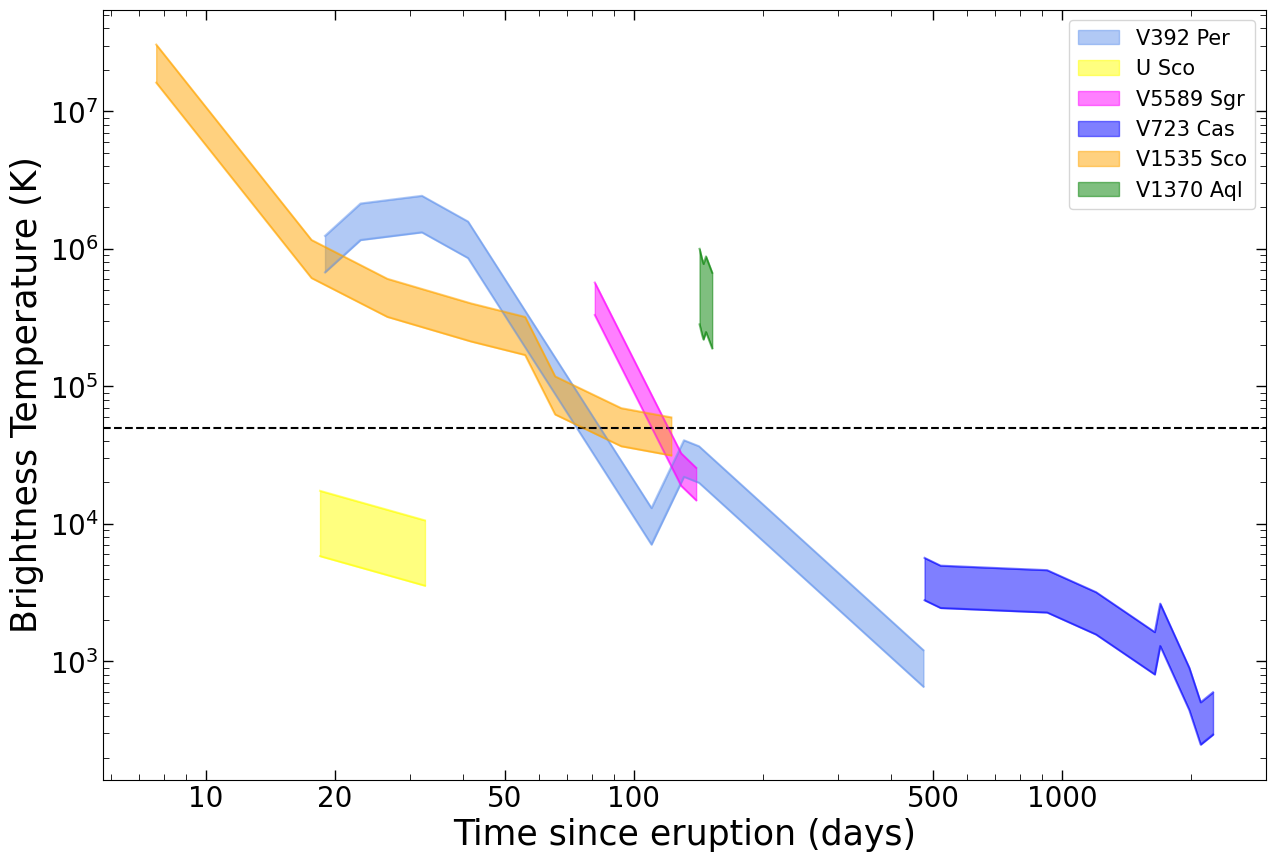

In [84]:
#plt.style.use('dark_background')
plt.style.use('tableau-colorblind10')

fig, ax = plt.subplots()
fig.set_size_inches(15,10)

ax.axhline(y=5*10**4, color='black', linestyle='--', linewidth=1.5)

## V392 Per ploting
ax.plot(day_1, v392_TBH[0], color = 'cornflowerblue', linestyle = '-', alpha=.50)
ax.plot(day_1, v392_TBL[0], color = 'cornflowerblue', linestyle = '-', alpha=.50)
ax.fill_between(day_1, v392_TBL[0], v392_TBH[0], color = 'cornflowerblue', alpha=.5, label="V392 Per")


#U Sco
ax.plot(day_8, u_TBH[0], color = 'yellow', linestyle = '-', alpha=.50)
ax.plot(day_8, u_TBL[0], color = 'yellow', linestyle = '-', alpha=.50)
ax.fill_between(day_8, u_TBL[0], u_TBH[0], color = 'yellow', alpha=.5, label="U Sco")


## V5589 Sgr plotting
ax.plot(day_2, v5589_TBH[0], color = 'fuchsia', linestyle = '-', alpha=.50)
ax.plot(day_2, v5589_TBL[0], color = 'fuchsia', linestyle = '-', alpha=.50)
ax.fill_between(day_2, v5589_TBL[0], v5589_TBH[0], color = 'fuchsia', alpha=.5, label="V5589 Sgr")

## V723 Cas plotting
ax.plot(day_7, v723_TBH[0], color = 'blue', linestyle = '-', alpha=.50)
ax.plot(day_7, v723_TBL[0], color = 'blue', linestyle = '-', alpha=.50)
ax.fill_between(day_7, v723_TBL[0], v723_TBH[0], color = 'blue', alpha=.5, label="V723 Cas")


## V1535 Sco Plotting
ax.plot(day_3, v1535_TBH[0], color = 'orange',  linestyle = '-', alpha=.50)
ax.plot(day_3, v1535_TBL[0], color = 'orange', linestyle = '-', alpha=.50)
ax.fill_between(day_3, v1535_TBL[0], v1535_TBH[0], color = 'orange',  alpha=.5, label="V1535 Sco")


#V1370 Aql 
ax.plot(day_11, v1370_TBH[0], color = 'green',  linestyle='-', alpha=.5)
ax.plot(day_11, v1370_TBL[0], color = 'green', linestyle='-', alpha=.5)
ax.fill_between(day_11, v1370_TBL[0], v1370_TBH[0], color = 'green', alpha=.5, label = 'V1370 Aql')


ax.set_xscale('log')
ax.set_xticks([10,20,50,100,500,1000], labels = ['10','20','50','100','500', '1000'], fontsize = 20)
plt.yticks(fontsize=20)
ax.set_yscale('log')
ax.set_xlabel("Time since eruption (days)", fontsize=25)
ax.set_ylabel("Brightness Temperature (K)", fontsize=25)


ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.tick_params(axis='both', which='major', length=7,width=1)
ax.tick_params(axis='both', which='minor', length=4)

plt.legend(title='', fontsize=15)
plt.savefig("Bright_Temp_SG.png")
plt.show();

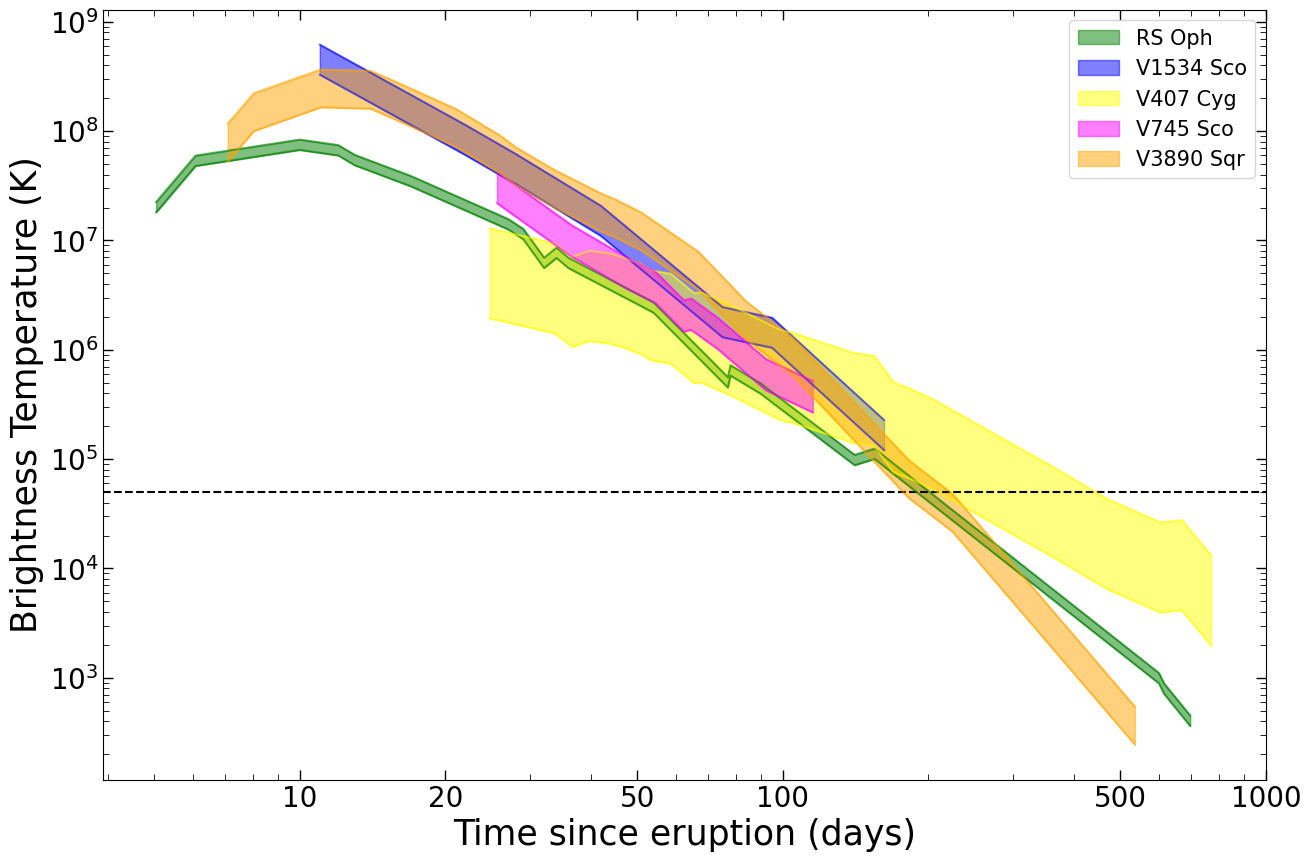

In [85]:
#plt.style.use('dark_background')
plt.style.use('tableau-colorblind10')

fig, ax = plt.subplots()
fig.set_size_inches(15,10)

ax.axhline(y=5*10**4, color='black', linestyle='--', linewidth=1.5)

## RS Oph Plotting
ax.plot(day_4, rs_TBH[0], color = 'green',  linestyle = '-', alpha=.60)
ax.plot(day_4, rs_TBL[0], color = 'green', linestyle = '-', alpha=.60)
ax.fill_between(day_4, rs_TBL[0], rs_TBH[0], color = 'green', alpha=.5, label = "RS Oph")

## V1534 Sco Plotting
ax.plot(day_5, v1534_TBH[0], color = 'blue', linestyle = '-', alpha=.50)
ax.plot(day_5, v1534_TBL[0], color = 'blue', linestyle = '-', alpha=.50)
ax.fill_between(day_5, v1534_TBL[0], v1534_TBH[0], color = 'blue',  alpha=.5,  label="V1534 Sco")

## V407 Cyg Plotting
ax.plot(day_6, v407_TBH[0], color = 'yellow', linestyle = '-', alpha=.50)
ax.plot(day_6, v407_TBL[0], color = 'yellow', linestyle = '-', alpha=.50)
ax.fill_between(day_6, v407_TBL[0],v407_TBH[0], color = 'yellow', alpha=.5, label="V407 Cyg")


#V745 Sco 
ax.plot(day_9, v745_TBH[0], color = 'fuchsia', linestyle='-', alpha=.5)
ax.plot(day_9, v745_TBL[0], color = 'fuchsia', linestyle='-', alpha=.5)
ax.fill_between(day_9, v745_TBL[0], v745_TBH[0], color = 'fuchsia', alpha=.5, label = 'V745 Sco')


#V3890 Sgr
ax.plot(day_10, v3890_TBH[0], color = 'orange', linestyle='-', alpha=.5)
ax.plot(day_10, v3890_TBL[0], color = 'orange',linestyle='-', alpha=.5)
ax.fill_between(day_10, v3890_TBL[0], v3890_TBH[0], color = 'orange',alpha=.5, label = 'V3890 Sqr')


ax.set_xscale('log')
ax.set_xticks([10,20,50,100,500,1000], labels = ['10','20','50','100','500', '1000'], fontsize = 20)
plt.yticks(fontsize=20)
ax.set_yscale('log')
ax.set_xlabel("Time since eruption (days)", fontsize=25)
ax.set_ylabel("Brightness Temperature (K)", fontsize=25)


ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)
ax.tick_params(axis='both', which='major', length=7,width=1)
ax.tick_params(axis='both', which='minor', length=4)

plt.legend(title='', fontsize=15)
plt.savefig("Bright_Temp_RG.png")
plt.show();